In [7]:
# import os
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import joblib

# # ===============================================================
# # 0. Setup output folders
# # ===============================================================

# MODEL_DIR = "../outputs/models/"
# PRED_DIR  = "../outputs/models/predictions/"

# os.makedirs(MODEL_DIR, exist_ok=True)
# os.makedirs(PRED_DIR, exist_ok=True)

# DATA_PATH = "../outputs/combine_analysis/final_training_dataset.csv"


# # ===============================================================
# # 1. Data Loading
# # ===============================================================

# def load_dataset(path):
#     """Load training dataset and return cleaned DataFrame."""
#     df = pd.read_csv(path)
#     print(f"Loaded dataset: {df.shape}")
#     return df


# # ===============================================================
# # 2. Feature Engineering Helpers
# # ===============================================================

# EXCLUDE_COLS = [
#     "StartDateTime", "EndDateTime",
#     "Perf_Filename", "ND_Filename",
#     "RunDateTime"
# ]

# TARGETS = {
#     "Throughput": "Perf_Avg_Throughput",
#     "Latency":    "Perf_Avg_Latency",
#     "Loss":       "Perf_Avg_Loss"
# }


# def extract_features(df):
#     """Return feature matrix X and dictionary of target vectors y."""
#     df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns], errors="ignore")

#     # Select numeric only
#     df_numeric = df.select_dtypes(include=[np.number])
#     print("Detected numeric columns:", df_numeric.shape[1])

#     # Targets
#     for tname, col in TARGETS.items():
#         if col not in df_numeric.columns:
#             raise ValueError(f"Missing target column in dataset: {col}")

#     # Features = all numeric except targets
#     feature_cols = [c for c in df_numeric.columns if c not in TARGETS.values()]
#     X = df_numeric[feature_cols].fillna(0)

#     # Target dict
#     y = { name: df_numeric[col].fillna(0) for name, col in TARGETS.items() }

#     print(f"Total ML features: {len(feature_cols)}")
#     return X, y, feature_cols


# # ===============================================================
# # 3. Scaling
# # ===============================================================

# def scale_features(X):
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
#     joblib.dump(scaler, os.path.join(MODEL_DIR, "lr_scaler.pkl"))
#     print("Scaler saved → outputs/models/lr_scaler.pkl")
#     return X_scaled


# # ===============================================================
# # 4. Train a Linear Regression Model
# # ===============================================================

# def train_single_lr_model(X_scaled, y, model_name):
#     """Train + evaluate + save LR model for one target."""
#     print("\n=================================================")
#     print(f" TRAINING LR MODEL FOR: {model_name}")
#     print("=================================================")

#     X_train, X_test, y_train, y_test = train_test_split(
#         X_scaled, y, test_size=0.2, random_state=42
#     )

#     lr = LinearRegression()
#     lr.fit(X_train, y_train)

#     # Save model
#     model_path = os.path.join(MODEL_DIR, f"lr_model_{model_name.lower()}.pkl")
#     joblib.dump(lr, model_path)
#     print(f"Model saved → {model_path}")

#     # Predictions
#     y_pred = lr.predict(X_test)

#     # Metrics
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     mae  = mean_absolute_error(y_test, y_pred)
#     r2   = r2_score(y_test, y_pred)

#     print(f"Results for {model_name}:")
#     print(f"  RMSE: {rmse:.4f}")
#     print(f"  MAE : {mae:.4f}")
#     print(f"  R²  : {r2:.4f}")

#     # Save predictions
#     pred_path = os.path.join(PRED_DIR, f"predictions_{model_name}.csv")
#     pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(pred_path, index=False)
#     print(f"Predictions saved → {pred_path}")

#     return {
#         "Model": model_name,
#         "RMSE": rmse,
#         "MAE": mae,
#         "R2": r2
#     }


# # ===============================================================
# # 5. Master Training Pipeline
# # ===============================================================

# def train_lr_pipeline():
#     """Main training pipeline used before ML model training."""

#     df = load_dataset(DATA_PATH)
#     X, y_dict, feature_cols = extract_features(df)
#     X_scaled = scale_features(X)

#     all_results = []

#     for model_name, target_col in TARGETS.items():
#         result = train_single_lr_model(
#             X_scaled=X_scaled,
#             y=y_dict[model_name],
#             model_name=model_name
#         )
#         all_results.append(result)

#     # Combined summary
#     print("\n\n==================== FINAL SUMMARY ====================")
#     for r in all_results:
#         print(f"{r['Model']} Model:")
#         print(f"  RMSE: {r['RMSE']:.4f}")
#         print(f"  MAE : {r['MAE']:.4f}")
#         print(f"  R²  : {r['R2']:.4f}")
#         print("")

#     return all_results


# # ===============================================================
# # Execute
# # ===============================================================

# if __name__ == "__main__":
#     train_lr_pipeline()


In [8]:
import os
import pandas as pd
import numpy as np

DATA_PATH = "../outputs/combine_analysis/final_training_dataset.csv"
SPLIT_DIR = "../outputs/datasets/"

os.makedirs(SPLIT_DIR, exist_ok=True)


def split_by_simulation(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Safely split dataset by simulation run.
    Each run = unique (RandSeed, RunDateTime).
    Guarantees ≥1 simulation in train, validation, and test.
    """

    runs = df.groupby(["RandSeed", "RunDateTime"]).size().reset_index()
    runs = runs.sample(frac=1, random_state=42)  # shuffle

    n = len(runs)

    if n < 3:
        raise ValueError(
            f"❌ Need at least 3 simulation runs for train/valid/test.\n"
            f"   Found only {n} runs.\n"
            f"   → Generate more NS-3 runs."
        )

    # Preliminary sizes
    n_train = max(1, int(train_ratio * n))
    n_val   = max(1, int(val_ratio * n))

    # Ensure test also has ≥1
    if n_train + n_val >= n:
        n_train = max(1, n - 2)
        n_val   = 1

    n_test = n - n_train - n_val

    train_runs = runs.iloc[:n_train]
    val_runs   = runs.iloc[n_train:n_train+n_val]
    test_runs  = runs.iloc[n_train+n_val:]

    def filter_subset(subset):
        return df.merge(
            subset[["RandSeed", "RunDateTime"]],
            on=["RandSeed", "RunDateTime"],
            how="inner"
        ).reset_index(drop=True)

    df_train = filter_subset(train_runs)
    df_val   = filter_subset(val_runs)
    df_test  = filter_subset(test_runs)

    print("\n=== Dataset Split Summary ===")
    print(f"Train: {df_train.shape} | simulations={len(train_runs)}")
    print(f"Valid: {df_val.shape}   | simulations={len(val_runs)}")
    print(f"Test : {df_test.shape}  | simulations={len(test_runs)}")

    df_train.to_csv(os.path.join(SPLIT_DIR, "train.csv"), index=False)
    df_val.to_csv(os.path.join(SPLIT_DIR, "valid.csv"), index=False)
    df_test.to_csv(os.path.join(SPLIT_DIR, "test.csv"), index=False)

    print(f"\nSaved split datasets → {SPLIT_DIR}")
    return df_train, df_val, df_test


def split():
    print("Loading:", DATA_PATH)
    df = pd.read_csv(DATA_PATH)
    split_by_simulation(df)


if __name__ == "__main__":
    split()


Loading: ../outputs/combine_analysis/final_training_dataset.csv

=== Dataset Split Summary ===
Train: (5, 110) | simulations=1
Valid: (6, 110)   | simulations=1
Test : (5, 110)  | simulations=1

Saved split datasets → ../outputs/datasets/


In [9]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"
DATA_DIR  = "../outputs/datasets/"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

TARGETS = {
    "Throughput": "Perf_Avg_Throughput",
    "Latency":    "Perf_Avg_Latency",
    "Loss":       "Perf_Avg_Loss"
}

EXCLUDE_COLS = [
    "StartDateTime", "EndDateTime",
    "Perf_Filename", "ND_Filename",
    "RunDateTime"
]


def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test


def extract_xy(df):
    df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns], errors="ignore")
    df_num = df.select_dtypes(include=[np.number])

    # Features = all numeric except targets
    feature_cols = [c for c in df_num.columns if c not in TARGETS.values()]
    X = df_num[feature_cols].fillna(0)

    # Targets
    y = {name: df_num[col].fillna(0) for name, col in TARGETS.items()}

    return X, y, feature_cols


def scale_data(X_train, X_valid, X_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_valid_s = scaler.transform(X_valid)
    X_test_s  = scaler.transform(X_test)

    joblib.dump(scaler, os.path.join(MODEL_DIR, "lr_scaler.pkl"))
    print("Scaler saved → outputs/models/lr_scaler.pkl")

    return X_train_s, X_valid_s, X_test_s

def train_single_lr_model(X_train, X_valid, X_test,
                          y_train, y_valid, y_test,
                          model_name):

    print("\n=================================================")
    print(f" TRAINING LR MODEL FOR: {model_name}")
    print("=================================================")

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Save model
    model_path = os.path.join(MODEL_DIR, f"lr_model_{model_name.lower()}.pkl")
    joblib.dump(model, model_path)
    print(f"Model saved → {model_path}")

    # Predictions
    y_valid_pred = model.predict(X_valid)
    y_test_pred  = model.predict(X_test)

    # Validation metrics
    val_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    val_mae  = mean_absolute_error(y_valid, y_valid_pred)
    val_r2   = r2_score(y_valid, y_valid_pred)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_r2   = r2_score(y_test, y_test_pred)

    print("Validation Results:")
    print(f"  RMSE: {val_rmse:.4f},  MAE: {val_mae:.4f},  R²: {val_r2:.4f}")

    print("Test Results:")
    print(f"  RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

    # --------------------------
    # Save VALIDATION predictions
    # --------------------------
    valid_path = os.path.join(PRED_DIR, f"{model_name}_valid_predictions.csv")
    pd.DataFrame({
        "y_true": y_valid,
        "y_pred": y_valid_pred
    }).to_csv(valid_path, index=False)
    print(f"Validation predictions saved → {valid_path}")

    # --------------------------
    # Save TEST predictions
    # --------------------------
    test_path = os.path.join(PRED_DIR, f"{model_name}_test_predictions.csv")
    pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }).to_csv(test_path, index=False)
    print(f"Test predictions saved → {test_path}")

    return {
        "Model": model_name,
        "Val_RMSE": val_rmse,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    }



def main():
    # Load datasets
    df_train, df_valid, df_test = load_split_data()

    # Extract features and targets
    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _ = extract_xy(df_valid)
    X_test,  y_test_dict, _  = extract_xy(df_test)

    # Scale
    X_train_s, X_valid_s, X_test_s = scale_data(X_train, X_valid, X_test)

    # Train LR models
    results = []
    for model_name in TARGETS.keys():
        r = train_single_lr_model(
            X_train_s, X_valid_s, X_test_s,
            y_train_dict[model_name],
            y_valid_dict[model_name],
            y_test_dict[model_name],
            model_name
        )
        results.append(r)

    print("\n\n==================== FINAL SUMMARY ====================")
    for r in results:
        print(r)


if __name__ == "__main__":
    main()


Scaler saved → outputs/models/lr_scaler.pkl

 TRAINING LR MODEL FOR: Throughput
Model saved → ../outputs/models/lr_model_throughput.pkl
Validation Results:
  RMSE: 0.0535,  MAE: 0.0535,  R²: 0.0000
Test Results:
  RMSE: 0.0024, MAE: 0.0024, R²: 0.0000
Validation predictions saved → ../outputs/models/predictions/Throughput_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/Throughput_test_predictions.csv

 TRAINING LR MODEL FOR: Latency
Model saved → ../outputs/models/lr_model_latency.pkl
Validation Results:
  RMSE: 13.2480,  MAE: 13.2480,  R²: 0.0000
Test Results:
  RMSE: 7.3269, MAE: 7.3269, R²: -4253192256641308105389769752576.0000
Validation predictions saved → ../outputs/models/predictions/Latency_valid_predictions.csv
Test predictions saved → ../outputs/models/predictions/Latency_test_predictions.csv

 TRAINING LR MODEL FOR: Loss
Model saved → ../outputs/models/lr_model_loss.pkl
Validation Results:
  RMSE: 0.8238,  MAE: 0.8238,  R²: 0.0000
Test Results:
 


=== Generating plots for Throughput ===
Saved → ../outputs/models/plots/Throughput_pred_vs_actual_valid.png


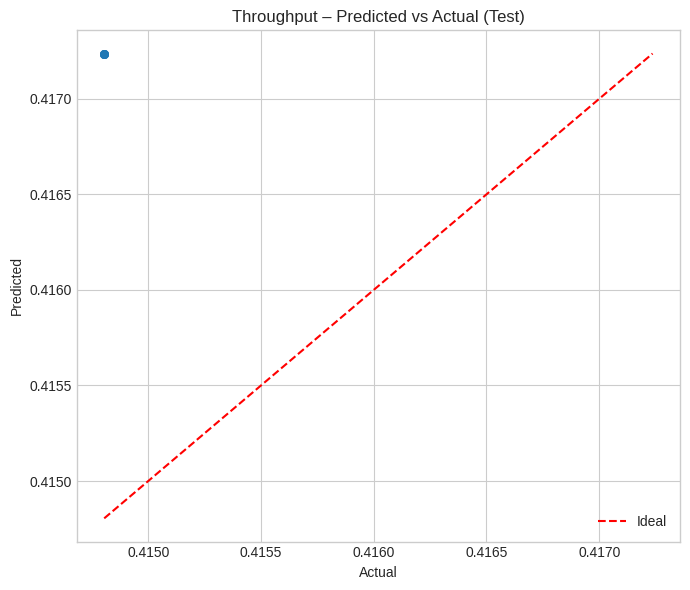

Saved → ../outputs/models/plots/Throughput_pred_vs_actual_test.png
Saved time-series plot → ../outputs/models/plots/Throughput_timeseries_valid.png


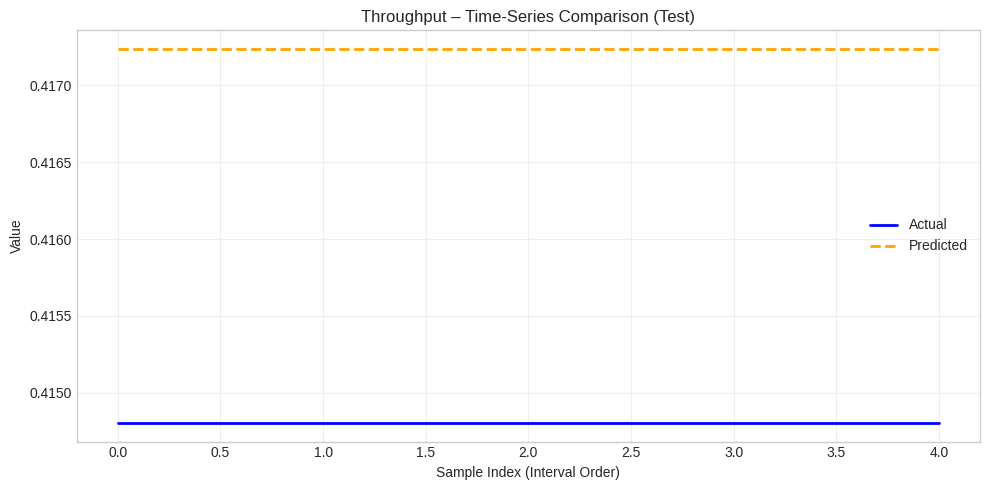

Saved time-series plot → ../outputs/models/plots/Throughput_timeseries_test.png

=== Generating plots for Latency ===
Saved → ../outputs/models/plots/Latency_pred_vs_actual_valid.png


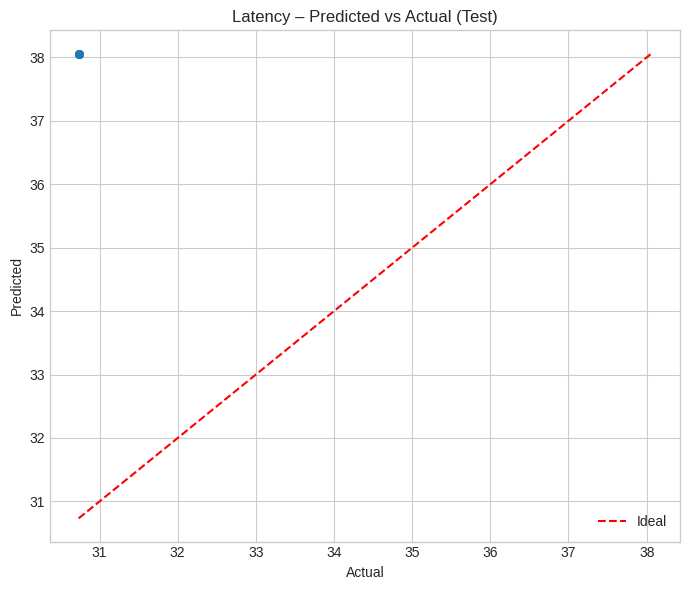

Saved → ../outputs/models/plots/Latency_pred_vs_actual_test.png
Saved time-series plot → ../outputs/models/plots/Latency_timeseries_valid.png


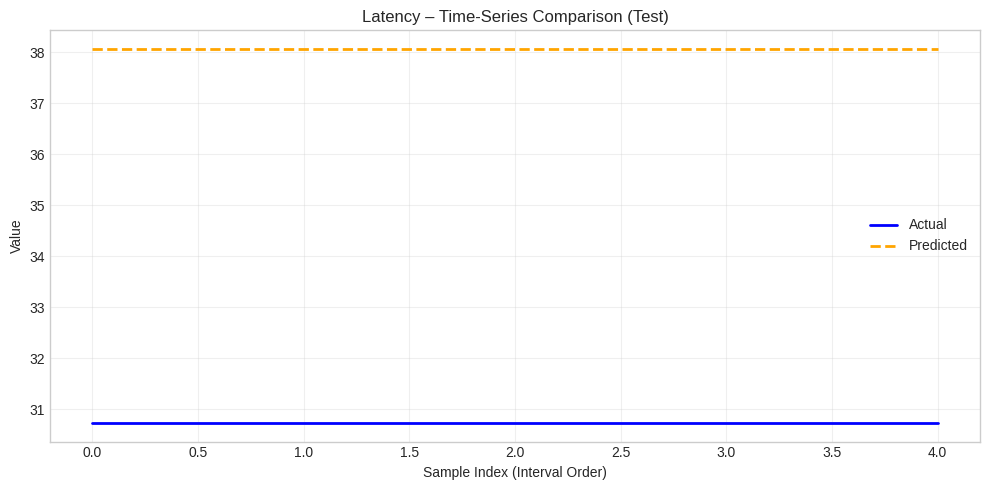

Saved time-series plot → ../outputs/models/plots/Latency_timeseries_test.png

=== Generating plots for Loss ===
Saved → ../outputs/models/plots/Loss_pred_vs_actual_valid.png


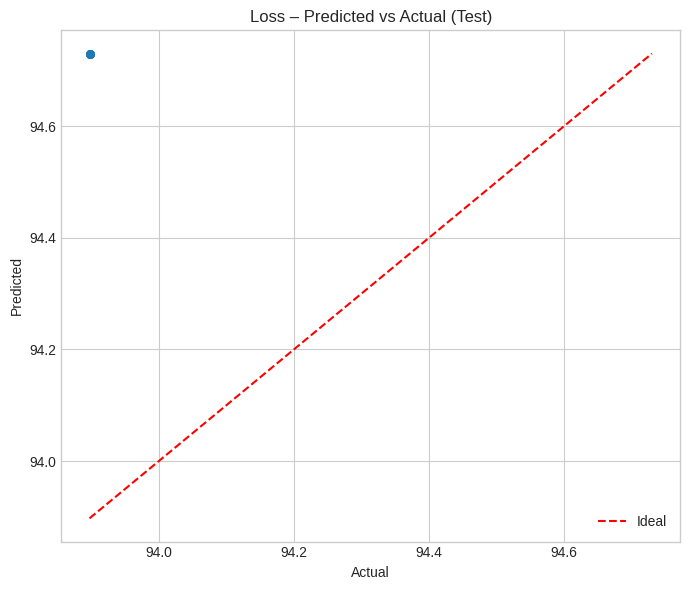

Saved → ../outputs/models/plots/Loss_pred_vs_actual_test.png
Saved time-series plot → ../outputs/models/plots/Loss_timeseries_valid.png


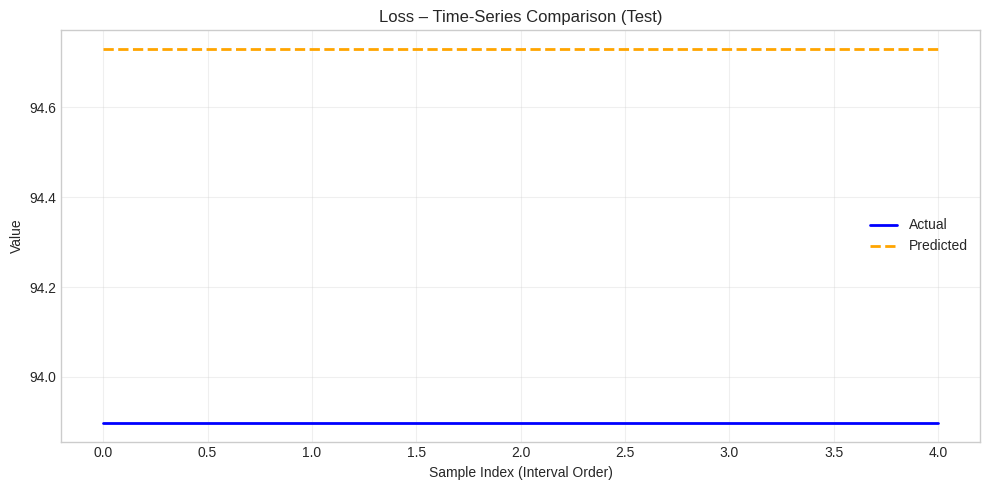

Saved time-series plot → ../outputs/models/plots/Loss_timeseries_test.png

All predicted-vs-actual plots generated!


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"

os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = ["Throughput", "Latency", "Loss"]

# Matplotlib style
plt.style.use("seaborn-v0_8-whitegrid")


def load_predictions(model_name, split):
    """
    Loads prediction CSV:
      split = "valid" or "test"
    """
    path = os.path.join(PRED_DIR, f"{model_name}_{split}_predictions.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file missing: {path}")
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_predicted_vs_actual(y_true, y_pred, title, outfile, showImage=False):
    """
    Scatter plot: Actual vs Predicted with identity line.
    showImage=True  → display plot
    showImage=False → save only (default)
    """

    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor=None)

    # Identity line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val],
             color="red", linestyle="--", label="Ideal")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    # Save plot
    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()     # display the plot
    else:
        plt.close()    # prevent GUI popups

    print(f"Saved → {outfile}")

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):
    """
    Time-series plot comparing Actual vs Predicted values.

    X-axis = index (interval order)
    y_true and y_pred must be same length.
    """

    plt.figure(figsize=(10, 5))

    plt.plot(y_true.values, label="Actual", color="blue", linewidth=2)
    plt.plot(y_pred, label="Predicted", color="orange", linestyle="--", linewidth=2)

    plt.title(title)
    plt.xlabel("Sample Index (Interval Order)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()

    print(f"Saved time-series plot → {outfile}")




def generate_all_plots():
    for model_name in MODELS:
        print(f"\n=== Generating plots for {model_name} ===")

        # Validation set
        yv, yv_pred = load_predictions(model_name, "valid")
        out_v = os.path.join(PLOT_DIR, f"{model_name}_pred_vs_actual_valid.png")
        plot_predicted_vs_actual(
            yv, yv_pred,
            title=f"{model_name} – Predicted vs Actual (Validation)",
            outfile=out_v
        )

        # Test set
        yt, yt_pred = load_predictions(model_name, "test")
        out_t = os.path.join(PLOT_DIR, f"{model_name}_pred_vs_actual_test.png")
        plot_predicted_vs_actual(
            yt, yt_pred,
            title=f"{model_name} – Predicted vs Actual (Test)",
            outfile=out_t,
            showImage=True
        )
        # Time-series (VALIDATION)
        ts_v = os.path.join(PLOT_DIR, f"{model_name}_timeseries_valid.png")
        plot_time_series(
            yv,
            yv_pred,
            title=f"{model_name} – Time-Series Comparison (Validation)",
            outfile=ts_v,
            showImage=False
        )

        # Time-series (TEST)
        ts_t = os.path.join(PLOT_DIR, f"{model_name}_timeseries_test.png")
        plot_time_series(
            yt,
            yt_pred,
            title=f"{model_name} – Time-Series Comparison (Test)",
            outfile=ts_t,
            showImage=True
        )

    

    print("\nAll predicted-vs-actual plots generated!")


if __name__ == "__main__":
    generate_all_plots()


In [ ]:
# import torch
# import time
# import psutil
# import os

# try:
#     from thop import profile
#     THOP_AVAILABLE = True
# except ImportError:
#     THOP_AVAILABLE = False
#     print("⚠ THOP not installed → FLOPs will use manual estimation.")


# # ======================================================================
# # 1. MODEL PARAMETER COUNT & SIZE (bytes / MB)
# # ======================================================================
# import torch
# import torch.nn as nn
# import joblib

# def load_lr_model(model_path, scaler_path, input_dim):
#     """
#     Load sklearn LR model and convert to PyTorch Linear.
#     Returns: sklearn_model, scaler, pytorch_model
#     """

#     # Load sklearn model and scaler
#     sk_model = joblib.load(model_path)
#     scaler = joblib.load(scaler_path)

#     # Build PyTorch model (1 output)
#     pt_model = nn.Linear(input_dim, 1)

#     # Assign weights correctly (ensure 2D shape)
#     w = torch.tensor(sk_model.coef_, dtype=torch.float32).reshape(1, -1)
#     b = torch.tensor(sk_model.intercept_, dtype=torch.float32)

#     pt_model.weight.data = w
#     pt_model.bias.data = b

#     return sk_model, scaler, pt_model


# def count_parameters(model):
#     """Returns total number of trainable parameters."""
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)


# def model_size_bytes(model, bytes_per_param=4):
#     """
#     Estimate model size in bytes.
#     float32 = 4 bytes; int8 = 1 byte.
#     """
#     n_params = count_parameters(model)
#     return n_params * bytes_per_param


# def model_size_megabytes(model, bytes_per_param=4):
#     return model_size_bytes(model, bytes_per_param) / (1024 ** 2)


# # ======================================================================
# # 2. FLOPs ESTIMATION
# # ======================================================================

# def compute_flops(model, example_input):
#     """
#     Returns FLOPs using THOP if available.
#     Otherwise returns None.
#     """
#     if THOP_AVAILABLE:
#         flops, params = profile(model, inputs=(example_input,), verbose=False)
#         return flops
#     else:
#         print("⚠ FLOPs unavailable (THOP not installed). Returning None.")
#         return None

# def compute_flops_lr(input_dim):
#     return 2 * input_dim   # multiply + add per feature


# # ======================================================================
# # 3. INFERENCE LATENCY (CPU/Edge Device)
# # ======================================================================

# def measure_latency(model, example_input, runs=100, warmup=10, device="cpu"):
#     model.eval()
#     model.to(device)

#     # Ensure correct shape
#     if example_input.ndim == 1:
#         example_input = example_input.unsqueeze(0)

#     example_input = example_input.to(device)

#     with torch.no_grad():

#         # Warmup
#         for _ in range(warmup):
#             _ = model(example_input)

#         # Timed runs
#         import time
#         t0 = time.perf_counter()
#         for _ in range(runs):
#             _ = model(example_input)
#         t1 = time.perf_counter()

#     return (t1 - t0) / runs



# # ======================================================================
# # 4. POWER & ENERGY MEASUREMENT (measurement-based)
# # ======================================================================

# def measure_power_cpu():
#     """
#     Returns CPU power consumption in Watts using psutil.
#     NOTE: This is an approximation; best is external USB meter.
#     """
#     try:
#         return psutil.sensors_battery().power_plugged  # often 0 on desktops
#     except:
#         return None


# def estimate_energy(latency, power_watts):
#     """
#     Energy = Power * Latency
#     """
#     if power_watts is None:
#         return None
#     return latency * power_watts


# # ======================================================================
# # 5. ENERGY VIA FLOPS ESTIMATION (model-based)
# # ======================================================================

# def estimate_energy_from_flops(flops, E_per_FLOP=5e-10):
#     """
#     E_est = FLOPs * E_per_FLOP
#     Default: 5e-10 J/FLOP (example from literature)
#     """
#     if flops is None:
#         return None
#     return flops * E_per_FLOP


# # ======================================================================
# # 6. PEAK ACTIVATION MEMORY ESTIMATION
# # ======================================================================

# def estimate_peak_activation_memory(example_output, bytes_per_activation=4):
#     """
#     Estimate peak activation memory from example model output.
#     """
#     return example_output.numel() * bytes_per_activation


# # ======================================================================
# # 7. FULL EDGE DEVICE METRICS (wrapper function)
# # ======================================================================

# def evaluate_edge_metrics(model, input_dim, device="cpu"):
#     dummy_input = torch.randn(1, input_dim)

#     # FLOPs
#     flops = compute_flops_lr(input_dim)

#     # Latency
#     latency = measure_latency(model, dummy_input, device=device)

#     # Parameters
#     params = sum(p.numel() for p in model.parameters())

#     # Model size (float32 = 4 bytes)
#     size_bytes = params * 4
#     size_mb = size_bytes / (1024 * 1024)

#     # Peak activation = output tensor size
#     with torch.no_grad():
#         out = model(dummy_input)
#     peak_act = out.numel() * 4

#     # Energy estimation (no power measurement)
#     E_est = flops * 5e-10

#     return {
#         "Parameters": params,
#         "Model Size (Bytes)": size_bytes,
#         "Model Size (MB)": size_mb,
#         "FLOPs": flops,
#         "Latency (s)": latency,
#         "Latency (ms)": latency * 1000,
#         "Energy Estimated (J)": E_est,
#         "Peak Activation Memory (Bytes)": peak_act
#     }

# def evaluate_model(pt_model, input_dim, device="cpu"):
#     return evaluate_edge_metrics(pt_model, input_dim, device=device)




⚠ THOP not installed → FLOPs will use manual estimation.


In [1]:
# Load saved LR model → both sklearn and PyTorch versions
from edge_evaluation import load_lr_model, evaluate_model

sk_model, scaler, pt_model = load_lr_model(
    "../outputs/models/lr_model_throughput.pkl",
    "../outputs/models/lr_scaler.pkl",
    input_dim=103
)

metrics = evaluate_model(pt_model, input_dim=103)
print(metrics)



{'Parameters': 104, 'Model Size (Bytes)': 416, 'Model Size (MB)': 0.000396728515625, 'FLOPs': 206, 'Latency (s)': 1.753639997332357e-05, 'Latency (ms)': 0.01753639997332357, 'Energy Estimated (J)': 1.0300000000000001e-07, 'Peak Activation Memory (Bytes)': 4}
